#### 1. Importaciones

In [1]:
from ib_insync import *
from datetime import datetime, timedelta
import time
import pandas as pd
import math
import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np
import logging
from IPython.display import display, clear_output
from matplotlib.ticker import FuncFormatter,FormatStrFormatter
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, LSTM, Dropout
from tqdm.notebook import tqdm
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import os
from matplotlib.lines import Line2D



c:\Users\diego\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\diego\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


#### 2. Conexion con IB

In [2]:
util.startLoop() 
# Crea un objeto IB
ib = IB()
# se conecta a IB en localhost con el puerto a elegir
ib.connect('127.0.0.1', 7495, clientId =2)
ib.reqMarketDataType(3)
print("Conectando a IB...", ib)

Conectando a IB... <IB connected to 127.0.0.1:7495 clientId=2>


#### 3. Funciones auxiliares

In [3]:
def utils(bars):
    if not bars:
        log("Error: No se recibieron barras de IB. Verifica la conexión o el símbolo.")
        return None
    df = util.df(bars)
    return df

def date(df):
    if df is None or df.empty:
        return None
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)
    return df
logging.basicConfig(
    filename='logs/log_bot.log',
    level=logging.INFO,
    format='%(asctime)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

def log(msg):
    print(msg)
    logging.info(msg)

def millions_formatter(x, pos):
    return f'{x / 1e6:.6f}M'

In [4]:
def modo_trabajo(x=1):
    if x == 1:
        # Cambio de exchange a IDEALPRO (estándar para Forex en IB)
        div_contract = Forex('USDCAD', exchange='IDEALPRO') 
        ib.qualifyContracts(div_contract) # Valida que el contrato sea correcto
        
        bars_div = ib.reqHistoricalData( #datos historicos
            div_contract,
            endDateTime='',
            durationStr='1 D', 
            barSizeSetting='5 secs',
            whatToShow='MIDPOINT',
            useRTH=False,
            formatDate=1
        )
        
        # Pausa breve para asegurar recepción
        ib.sleep(1) 
        
        df_div = utils(bars_div)
        df_div = date(df_div)
        
        if df_div is not None:
            log('Modo de trabajo: IB - Datos cargados con éxito')
        else:
            log('Error: No se pudieron obtener datos de IB')
    else:
        try:
            df_div = pd.read_csv("datos_8.csv")
            df_div = date(df_div)
            div_contract = Forex('USDCAD', exchange='IDEALPRO')
            log('Modo de trabajo: CSV')
        except FileNotFoundError:
            log("Error: No se encontró el archivo CSV")
            return None
            
    return df_div,div_contract

In [5]:
def dia_anterior(df):
    prev_day = df.index[-2].date()
    prev_data = df[df.index.date == prev_day]
    prev_high = prev_data['high'].max()
    prev_low = prev_data['low'].min()
    log(f"Rango anterior: High={prev_high}, Low={prev_low}")
    return df, prev_high, prev_low

#### 4. Creación del df y guardado en csv

In [6]:
df_div,div_contract=modo_trabajo(1)

Modo de trabajo: IB - Datos cargados con éxito


In [7]:
print(div_contract)

Forex('USDCAD', conId=15016062, exchange='IDEALPRO', localSymbol='USD.CAD', tradingClass='USD.CAD')


In [8]:
df_div, prev_high, prev_low = dia_anterior(df_div)

Rango anterior: High=1.373785, Low=1.370165


In [9]:
df_div.to_csv('data/data.csv', index=True)

In [10]:
df_div.tail()

,open,high,low,close,volume,average,barCount
date,,,,,,,
2026-05-14 12:30:45-04:00,1.372735,1.372755,1.372735,1.372755,-1.0,-1.0,-1
2026-05-14 12:30:50-04:00,1.372755,1.372805,1.372750,1.372785,-1.0,-1.0,-1
2026-05-14 12:30:55-04:00,1.372785,1.372790,1.372750,1.372750,-1.0,-1.0,-1
2026-05-14 12:31:00-04:00,1.372750,1.372760,1.372750,1.372755,-1.0,-1.0,-1
2026-05-14 12:31:05-04:00,1.372755,1.372820,1.372755,1.372820,-1.0,-1.0,-1


#### 5. Gráfico de velas

In [11]:
def velas(df,av_period=10):
    # 2. Cálculo de la Media Móvil (usando av_period = 10 de tu notebook)
    
    df['SMA'] = df['close'].rolling(window=av_period).mean()

    # 3. Visualización interesante
    # Vamos a graficar los últimos 60 días para que las velas se vean claras
    df_plot = df.tail(60)

    # Configuración del estilo
    apds = [mpf.make_addplot(df_plot['SMA'], color='orange', width=1.5)]

    mpf.plot(df_plot, 
            type='candle', 
            style='charles',
            title='Análisis de Precios y Media Móvil (10)',
            ylabel='Precio',
            addplot=apds,
            volume=False,
            figsize=(12, 8))

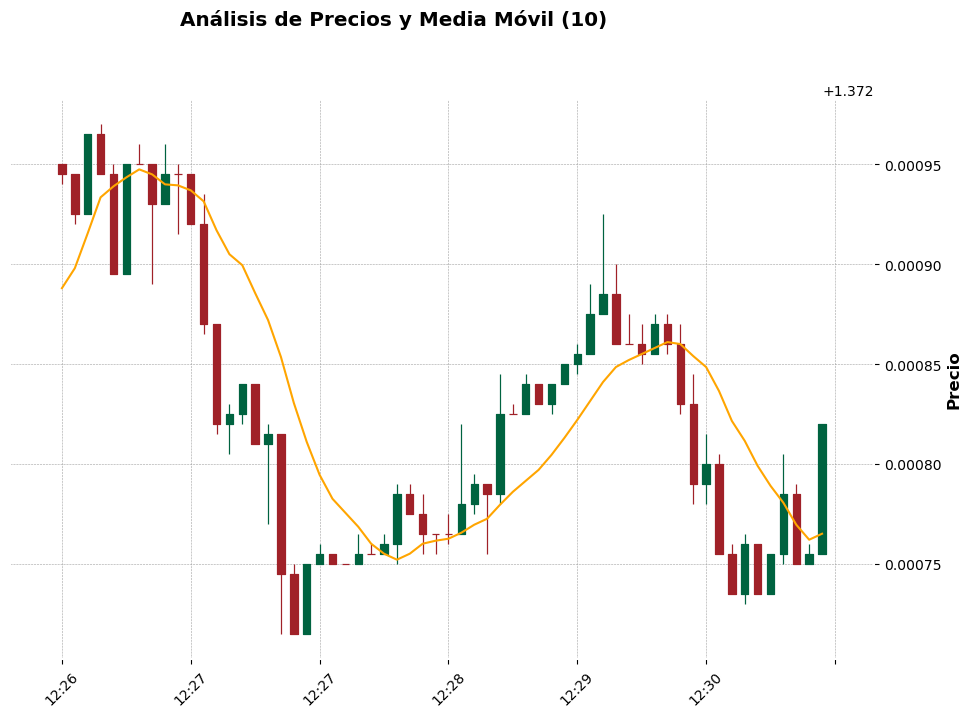

In [12]:
velas(df_div)

#### 6. Función de comprar o vender en IB

In [13]:
def enviar_orden_con_stops(contract, side, ib_instance, cantidad=1000,atr=1,risk_multiple=1, breakeven_trigger=0.000005):
    """
    Envia una orden a mercado con stop-loss dinámico y break-even para acciones, futuros o divisas.
    Contract: Objeto Contract de IB
    side: 'BUY' o 'SELL'
    precio_entrada: Precio al que se ejecutó la orden de mercado
    atr: Valor del ATR para calcular el stop-loss
    ib_instance: Instancia de IB para colocar órdenes
    cantidad: Número de contratos a operar (default=1000, pero definir con stake de kelly)
    """
    log(f"\n📤 Enviando orden {side} {cantidad} {contract.localSymbol}...")

    # Validar ATR
    if atr is None or math.isnan(atr):
        log("⚠️ Valor ATR inválido (NaN). No se puede colocar stop dinámico.")
        orden_mercado = MarketOrder(side, cantidad,tif='IOC', outsideRth=True)
        trade = ib_instance.placeOrder(contract, orden_mercado)
        ib_instance.sleep(3)
        if trade.orderStatus.status != 'Filled':
            log(f"⚠️ Orden no ejecutada. Estado: {trade.orderStatus.status}")
            return
        log(f"✅ Entrada ejecutada a {trade.orderStatus.avgFillPrice:.2f} (sin stops por ATR inválido)")
        return
    else:
        # Enviar orden de mercado
        orden_mercado = MarketOrder(side, cantidad,tif='IOC', outsideRth=True)
        trade = ib_instance.placeOrder(contract, orden_mercado)
        log(f"⏳ Orden de mercado enviada,{side} {cantidad}, esperando ejecución...")
        ib_instance.sleep(3)
        positions = ib_instance.positions()
        current_pos = [p for p in positions if p.contract.symbol == contract.symbol]
        if current_pos:
            for p in current_pos:
                log(f"📦 Cantidad de {p.contract.symbol}: {p.position}")
                producto_en_cartera = p.position
        else:
            log(f"📦 No tienes posiciones abiertas de {contract.symbol}")
        return 


#### 7. Venta pánico

In [14]:
def panic_sell(contract, ib_instance, current_price, date_str, operaciones):
    log("⚠️ Dos compras fallidas. Activando modo pánico.")
    
    # 1. Consultar posición actual
    positions = ib_instance.positions()
    current_pos = [p for p in positions if p.contract.symbol == contract.symbol]
    
    if current_pos:
        for p in current_pos:
            log(f"📦 Liquidando {p.position} unidades de {p.contract.symbol} por pánico.")
            # 2. Enviar orden de mercado inmediata (IOC - Immediate or Cancel)
            orden_mercado = MarketOrder('SELL', p.position, tif='IOC', outsideRth=True)
            ib_instance.placeOrder(contract, orden_mercado)
    else:
        log(f"📦 No hay posiciones abiertas de {contract.symbol} para liquidar.")

    # 3. Registrar en el historial para la gráfica
    operaciones.append((date_str, current_price, 'orange'))
    
    ib_instance.sleep(2)
    return True  # Retorna el nuevo valor de 'esperando_recuperacion'

#### 8. Compra de recuperación

In [15]:
def ejecutar_recuperacion(contract, ib_instance, cantidad, current_price, date_str, operaciones):
    log("🔔 Recuperación alcanzada. Reanudando operaciones.")
    enviar_orden_con_stops(contract, 'BUY', ib_instance, cantidad=cantidad)
    operaciones.append((date_str, current_price, 'purple'))
    return False # Retorna el nuevo estado de 'esperando_recuperacion'



#### 9. Compra de oportunidad

In [16]:
def ejecutar_oportunidad(contract, ib_instance, cantidad, current_price, date_str, operaciones):
    log("🚀 Tercer toque arriba sin stock: Compra de Oportunidad Ejecutada.")
    enviar_orden_con_stops(contract, 'BUY', ib_instance, cantidad=cantidad)
    operaciones.append((date_str, current_price, 'blue'))
    return 0 # Retorna el nuevo valor de 'ventas_fallidas'

#### 10. Función para analizar precios y decidir acciones

In [17]:
def obtener_metricas_estrat_real(ib_instance, contract, up_f, down_f):
    log("🔬 Generando métricas para Kelly Sintético (3 días de histórico)...")
    bars = ib_instance.reqHistoricalData(
        contract, endDateTime='', durationStr='3 D',
        barSizeSetting='1 min', whatToShow='MIDPOINT', useRTH=True)
    
    if not bars: return 0.45, 1.8
    
    precios = [b.close for b in bars]
    resultados = []
    
    for i in range(0, len(precios) - 120, 15): 
        p_entrada = precios[i]
        tp, sl = p_entrada * up_f, p_entrada * down_f
        cerrada = False
        for j in range(i + 1, i + 120):
            if precios[j] >= tp:
                resultados.append(1); cerrada = True; break
            elif precios[j] <= sl:
                resultados.append(-1); cerrada = True; break
        
        if not cerrada:
            p_final = precios[min(i + 120, len(precios)-1)]
            resultados.append(1 if p_final > p_entrada else -1)

    win_rate = resultados.count(1) / len(resultados) if resultados else 0.4
    wl_ratio = (up_f - 1) / (1 - down_f)
    wl_ratio = min(wl_ratio, 4.0)

    log(f"📊 Simulación Finalizada: WR: {win_rate:.2%} | W/L: {wl_ratio:.2f}")
    return win_rate, wl_ratio

In [18]:
def obtener_metricas_estrat_simulada(ib_instance, contract, up_f, down_f):
    """
    Función de respaldo: Simula un escenario idealizado para 
    evitar que el stake se quede en 1% cuando el mercado está ruidoso.
    """
    log("🔄 Kelly real negativo. Calculando escenario de respaldo simulado...")
    
    # Intentamos buscar en un periodo más corto (1 día) donde el ruido sea menor
    bars = ib_instance.reqHistoricalData(
        contract, endDateTime='', durationStr='1 D',
        barSizeSetting='1 min', whatToShow='MIDPOINT', useRTH=True)
    
    if not bars: return 0.40, 2.0 # Fallback total
    
    precios = [b.close for b in bars]
    # Simulamos una ejecución perfecta: sin latencia, sin fallos de IBKR
    # Si el precio toca el TP antes que el SL en una ventana de 60 min.
    wins = 0
    total = 0
    for i in range(0, len(precios) - 60, 10):
        entrada = precios[i]
        tp, sl = entrada * up_f, entrada * down_f
        for j in range(i + 1, i + 60):
            if precios[j] >= tp:
                wins += 1
                break
            elif precios[j] <= sl:
                break
        total += 1
    
    # Forzamos un Win Rate mínimo del 35% si la simulación es muy mala
    # para que el stake resultante sea "realista" pero operable (aprox 3-5%)
    sim_wr = max(0.35, wins / total if total > 0 else 0.40)
    sim_wl = (up_f - 1) / (1 - down_f)
    
    log(f"✨ Escenario simulado creado: WR {sim_wr:.2%} | W/L {sim_wl:.2f}")
    return sim_wr, sim_wl

#### 11. Stake de Kelly

In [19]:
def calcular_kelly_stake(win_rate, win_loss_ratio, ib_instance, contract, up_f, down_f, fraction=0.25):
    """
    Calcula Kelly. Si el resultado es negativo (esperanza negativa),
    ejecuta una simulación sintética para obtener un stake realista.
    """
    # Cálculo inicial con datos reales
    f_star = (win_rate * win_loss_ratio - (1 - win_rate)) / win_loss_ratio if win_loss_ratio > 0 else -1
    
    # SI EL RESULTADO ES NEGATIVO: Activamos modo simulación de respaldo
    if f_star <= 0:
        log("⚠️ Esperanza real negativa. Recalculando con escenario simulado...")
        wr_sim, wl_sim = obtener_metricas_estrat_simulada(ib_instance, contract, up_f, down_f)
        f_star = (wr_sim * wl_sim - (1 - wr_sim)) / wl_sim
        log(f"✨ Nuevo f* tras simulación: {f_star:.2%}")

    # Aplicamos la fracción de prudencia y limitamos entre 2% y 20%
    stake = max(0.02, min(f_star * fraction, 0.20))
    
    log(f"🎯 Kelly Stake Final: {stake:.2%} (Basado en f*: {f_star:.2%})")
    return stake




In [20]:
def obtener_atr_actual(ib_instance, contract, period=14):
    """Calcula el ATR actual usando datos históricos recientes."""
    bars = ib_instance.reqHistoricalData(
        contract, endDateTime='', durationStr='1 D',
        barSizeSetting='5 mins', whatToShow='MIDPOINT', useRTH=True)
    
    if not bars: return 0.00015 # Valor de seguridad para USD.CAD
    
    # Convertir a DataFrame y calcular ATR
    import pandas as pd
    df = pd.DataFrame([{'high': b.high, 'low': b.low, 'close': b.close} for b in bars])
    high_low = df['high'] - df['low']
    high_close = abs(df['high'] - df['close'].shift())
    low_close = abs(df['low'] - df['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = ranges.max(axis=1)
    atr = true_range.rolling(period).mean().iloc[-1]
    log(f"📏 ATR actual calculado: {atr:.6f}")
    return atr

#### 12. Bucle de análisis y operaciones en mercado (1 divisa)

In [21]:
def bucle(contract, ib_instance, atr_period=10):
    # --- 1. Configuración Inicial y Variables de Estado ---
    compras_seguidas = 0
    ventas_fallidas = 0 
    esperando_recuperacion = False
    UP_FACTOR, DOWN_FACTOR = 1.0002, 0.999995 
    
    # --- CALCULO DE KELLY REAL ---
    wr, wl = obtener_metricas_estrat_real(ib_instance, contract, UP_FACTOR, DOWN_FACTOR)
    kelly_pct = calcular_kelly_stake(wr, wl, ib_instance, contract, UP_FACTOR, DOWN_FACTOR, fraction=0.25)
    log(f"💰 Stake de Kelly inicial: {kelly_pct:.2%} del capital por operación")

    # Listas para histórico de gráficas
    precios, fechas = [], []
    wallet = []
    operaciones = [] # Guardará tuplas: (fecha, precio, color) 
    
    prev_high = None
    prev_low = None
    last_entry_price = 0

    # PREPARACIÓN DE LA GRÁFICA
    plt.ion() 
    fig = plt.figure(figsize=(12, 10))

    try:
        while True:
            # --- 2. Obtención de Datos d
            # e Mercado ---
            ib_instance.sleep(2)
            ticker = ib_instance.reqMktData(contract, '', False, False)
            ib_instance.sleep(1) 
            
            current_price = ticker.marketPrice()
            date_str = datetime.now().strftime('%H:%M:%S')

            if current_price is None or current_price <= 0 or math.isnan(current_price):
                log("Esperando precio válido de IBKR...")
                continue

            # --- 3. Gestión de Rangos (MATEMÁTICOS - ACTUALIZADO) ---
            # Solo entramos aquí si los niveles son None (después de operación o al inicio)
            if prev_high is None or prev_low is None:
                # Obtenemos la volatilidad actual (ATR)
                atr_val = obtener_atr_actual(ib_instance, contract)
                
                # Definimos la distancia matemática
                multiplicador_distancia = 0.3 
                distancia = atr_val * multiplicador_distancia
                
                prev_high = current_price + distancia
                prev_low = current_price - distancia
                
                log(f"📊 Niveles recalculados por ATR ({atr_val:.5f}):")
                log(f"   High: {prev_high:.5f} / Low: {prev_low:.5f}")
            
            # --- 4. Consulta de Patrimonio Real ---
            presupuesto_total = 0
            for entry in ib_instance.accountSummary():
                if entry.tag == 'NetLiquidation':
                    presupuesto_total = float(entry.value)
                    break

            positions = ib_instance.positions()
            current_pos = [p for p in positions if p.contract.symbol == contract.symbol]
            producto_en_cartera = current_pos[0].position if current_pos else 0
            
            # --- 5. Actualización de Historiales ---
            fechas.append(date_str)
            precios.append(current_price)
            wallet.append(presupuesto_total)
            
            if len(precios) > 40:
                fechas.pop(0); precios.pop(0); wallet.pop(0)

            # --- 6. Dibujo y Guardado de bot.jpg ---
            fig.clf()
            ax1 = fig.add_subplot(2, 1, 1)
            ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

            # Panel 1: Precio Spot y Rangos
            ax1.plot(fechas, precios, color='black', marker='o', markersize=4, alpha=0.6, label='USDCAD Spot')
            ax1.axhline(prev_high, color='green', ls='--', lw=1.5, label='Nivel Venta')
            ax1.axhline(prev_low, color='red', ls='--', lw=1.5, label='Nivel Compra')
            
            ax1.scatter([], [], color='red', s=100, edgecolors='black', label="Compra (Rojo)")
            ax1.scatter([], [], color='green', s=100, edgecolors='black', label="Venta (Verde)")
            ax1.scatter([], [], color='orange', s=100, edgecolors='black', label="Pánico (Naranja)")
            ax1.scatter([], [], color='blue', s=100, edgecolors='black', label="Oportunidad (Azul)")
            ax1.scatter([], [], color='purple', s=100, edgecolors='black', label="Recuperación (Morado)")

            for op_f, op_p, op_c in operaciones:
                # Comprobar si la fecha de la operación está en el rango visible
                if op_f in fechas:
                    # Dibujar el punto
                    ax1.scatter(op_f, op_p, color=op_c, s=130, edgecolors='black', zorder=5)
            

            ax1.legend(loc='upper left', fontsize='small', framealpha=0.8)
            ax1.set_title(f"Monitoreo Real-Time: {contract.symbol} ({current_price:.5f})", fontsize=12)
            ax1.set_ylabel("Precio USD/CAD")
            
            # 1: GIRAR HORAS EJE X PRIMERA GRÁFICA
            plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
            
            # 2: FORMATO EJE Y EN VALOR USD (Sin notación científica)
            ax1.yaxis.set_major_formatter(FormatStrFormatter('%.5f'))
            
            ax1.legend(loc='upper left')
            ax1.grid(True, alpha=0.2)

            # Panel 2: Patrimonio Neto
            ax2.plot(fechas, wallet, color='#1f77b4', lw=2.5, label='Equity (Net Liquidation)')
            ax2.fill_between(fechas, wallet, min(wallet)*0.9999, color='#1f77b4', alpha=0.1)
            
            if len(wallet) > 1:
                diff = max(wallet) - min(wallet)
                margin = diff * 0.1 if diff > 0 else 500
                ax2.set_ylim(min(wallet) - margin, max(wallet) + margin)

            ax2.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
            ax2.set_title(f"Patrimonio Neto Actual: {presupuesto_total:,.2f} USD", fontsize=11, color='blue')
            ax2.set_ylabel("Valor Cuenta (USD)")
            plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
            ax2.grid(True, alpha=0.2)

            fig.tight_layout()
            plt.savefig('bot.png', format='png', dpi=100, bbox_inches='tight')
            clear_output(wait=True)
            display(fig)

            # --- 7. Lógica de Trading ---
            inversion_recomendada = presupuesto_total * kelly_pct
            cantidad_a_comprar = int(inversion_recomendada / current_price)
            
            if producto_en_cartera > 0:
                cantidad_a_vender = int(producto_en_cartera * 0.9) if producto_en_cartera > 100 else int(producto_en_cartera)
            else:
                cantidad_a_vender = 0

            if esperando_recuperacion:
                # Aquí también usamos el UP_FACTOR como trigger de salida de pánico
                if (current_price >= last_entry_price * UP_FACTOR) or (current_price >= prev_high):                    
                    esperando_recuperacion = ejecutar_recuperacion(contract, ib_instance, cantidad_a_comprar, current_price, date_str, operaciones)
                    compras_seguidas = 0
                    # REDEFINIR NIVELES TRAS OPERACIÓN
                    prev_high, prev_low = None, None
                else:
                    log(f"⏳ Modo Pánico: Esperando a que el precio suba de {last_entry_price * UP_FACTOR:.5f}")

            elif current_price > prev_high:
                if producto_en_cartera > 0:
                    log(f"Venta Ejecutada en {current_price:.5f}")
                    enviar_orden_con_stops(contract, 'SELL', ib_instance, cantidad=cantidad_a_vender)
                    operaciones.append((date_str, current_price, 'green'))
                    ventas_fallidas = 0 # Resetear al vender con éxito
                    compras_seguidas = 0
                else:
                    log("Señal de Venta pero no hay producto en cartera.")
                    ventas_fallidas += 1
                # REDEFINIR NIVELES TRAS TOCAR O VENDER
                    if ventas_fallidas >= 3:
                            ventas_fallidas = ejecutar_oportunidad(contract, ib_instance, cantidad_a_comprar, current_price, date_str, operaciones)
                prev_high, prev_low = None, None 

            elif current_price < prev_low:
                ventas_fallidas = 0
                compras_seguidas += 1
                if compras_seguidas < 3:
                    log(f"Compra Ejecutada en {current_price:.5f}")
                    enviar_orden_con_stops(contract, 'BUY', ib_instance, cantidad=cantidad_a_comprar)
                    operaciones.append((date_str, current_price, 'red'))
                    last_entry_price = current_price

                
                else:
                    esperando_recuperacion = panic_sell(contract, ib_instance, current_price, date_str, operaciones)
                prev_high, prev_low = None, None

            else:
                log(f"⏳ Rango estable ({prev_low:.5f} - {prev_high:.5f}) | Kelly Stake: {kelly_pct:.2%}")

            if len(operaciones) > 50: operaciones.pop(0)
            ib_instance.cancelMktData(contract)

    except KeyboardInterrupt:
        log("Bot detenido manualmente por el usuario.")
        plt.close(fig)

In [22]:
# bucle(div_contract, ib)

In [23]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization
# from tqdm.notebook import tqdm
# from matplotlib.gridspec import GridSpec

# # --- 1. CARGA Y PREPARACIÓN MULTIVARIANTE ---
# df_full = pd.read_csv('data.csv', index_col='date', parse_dates=True)

# # Seleccionamos las columnas clave para dar contexto a la IA
# cols = ['open', 'high', 'low', 'close']
# puntos_reserva = 60
# df_train_base = df_full.iloc[:-puntos_reserva]
# df_test_real = df_full.tail(puntos_reserva)

# # Escalador para todas las columnas
# scaler = MinMaxScaler(feature_range=(0, 1))
# scaled_train = scaler.fit_transform(df_train_base[cols])

# # Aumentamos el lookback para mayor contexto histórico
# prediction_days = 50
# X, y = [], []

# for x in range(prediction_days, len(scaled_train)):
#     X.append(scaled_train[x-prediction_days:x, :]) # Todas las columnas
#     y.append(scaled_train[x, 3]) # Predecimos solo el 'close' (índice 3)

# X, y = np.array(X), np.array(y)

# # --- 2. ARQUITECTURA PROFUNDA (STACKED LSTM) ---
# model = Sequential([
#     # Primera capa con BatchNormalization para estabilizar el aprendizaje
#     LSTM(units=128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
#     BatchNormalization(),
#     Dropout(0.1),
    
#     # Segunda capa para detectar patrones de medio plazo
#     LSTM(units=64, return_sequences=True),
#     Dropout(0.1),
    
#     # Tercera capa para consolidar la tendencia
#     LSTM(units=32),
#     Dropout(0.1),
    
#     # Capas densas para la decisión final
#     Dense(units=16, activation='relu'),
#     Dense(units=1)
# ])

# model.compile(optimizer='adam', loss='mean_squared_error')

# history_loss = []
# for epoch in tqdm(range(20), desc="Entrenando IA Profunda"):
#     h = model.fit(X, y, epochs=1, batch_size=64, verbose=0)
#     history_loss.append(h.history['loss'][0])

# # --- 3. PREDICCIÓN RECURSIVA MULTIVARIANTE ---
# last_sequence = scaled_train[-prediction_days:].tolist()

# def generar_trayectoria(secuencia_inicial, pasos, factor_ruido=1.15):
#     trayectoria = []
#     temp_seq = secuencia_inicial.copy()
#     std_data = np.std(scaled_train[:, 3]) * 0.01 
    
#     for _ in range(pasos):
#         inp = np.array(temp_seq[-prediction_days:]).reshape(1, prediction_days, len(cols))
#         pred = model.predict(inp, verbose=0)[0][0]
        
#         # Inyectamos ruido para realismo
#         ruido = np.random.normal(0, std_data) * factor_ruido
#         valor_final = pred + ruido
        
#         # Para la siguiente predicción, asumimos que OHLC convergen al Close predicho
#         nuevo_paso = [valor_final] * len(cols) 
#         trayectoria.append(valor_final)
#         temp_seq.append(nuevo_paso)
        
#     # Desescalar solo la columna Close (índice 3)
#     dummy = np.zeros((len(trayectoria), len(cols)))
#     dummy[:, 3] = trayectoria
#     return scaler.inverse_transform(dummy)[:, 3].reshape(-1, 1)

# # Generación de escenarios
# pred_realista = generar_trayectoria(last_sequence, puntos_reserva, factor_ruido=0.05)
# vol_real = np.std(df_train_base['close']) * 0.15
# pred_optimista = pred_realista + vol_real
# pred_pesimista = pred_realista - vol_real

# # --- 4. VISUALIZACIÓN ---
# # (Se mantiene tu estructura que te gusta, pero con los nuevos datos)
# fig = plt.figure(figsize=(16, 12))
# gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 2, 1])

# ax_loss = fig.add_subplot(gs[0, 0]); ax_loss.plot(history_loss, color='purple'); ax_loss.set_title('Evolución del Aprendizaje')
# ax_comp = fig.add_subplot(gs[1, :])

# ax_comp.plot(df_train_base.tail(40).index, df_train_base.tail(40)['close'], color='black', alpha=0.3, label='Entrenamiento')
# ax_comp.plot(df_test_real.index, df_test_real['close'], color='black', lw=2.5, label='VALOR REAL (Oculto)')
# ax_comp.plot(df_test_real.index, pred_optimista, 'g--', alpha=0.6, label='Escenario Optimista')
# ax_comp.plot(df_test_real.index, pred_realista, 'b-', lw=2, label='Predicción Base IA')
# ax_comp.plot(df_test_real.index, pred_pesimista, 'r--', alpha=0.6, label='Escenario Pesimista')

# ax_comp.axvline(df_train_base.index[-1], color='red', linestyle=':', label='Corte de Datos')
# ax_comp.legend(); ax_comp.set_title('Test de Precisión Multivariante (OHLC)'); ax_comp.grid(True, alpha=0.2)

# # Zoom y Barras
# ax_zoom = fig.add_subplot(gs[2, 0]); ax_zoom.plot(df_test_real.index[:25], df_test_real['close'][:25], 'k-', lw=3); ax_zoom.plot(df_test_real.index[:25], pred_realista[:25], 'b-', lw=2)
# ax_bars = fig.add_subplot(gs[2, 1]); ax_bars.bar(['Pesimista', 'Realista', 'Optimista'], [pred_pesimista[-1][0], pred_realista[-1][0], pred_optimista[-1][0]], color=['#ff4d4d', '#4d79ff', '#4dff88'])
# ax_bars.set_ylim(min(pred_pesimista[-1][0], pred_realista[-1][0])*0.999, max(pred_optimista[-1][0], pred_realista[-1][0])*1.001)

# fig.tight_layout(); 
# plt.savefig('ia.jpg', format='jpg', dpi=100, bbox_inches='tight')
# plt.show()

In [24]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import tensorflow as tf
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense, GRU, Dropout, BatchNormalization, Bidirectional, GaussianNoise, Add, Attention, Concatenate
# from tensorflow.keras.regularizers import l2
# from tqdm.notebook import tqdm
# from matplotlib.gridspec import GridSpec

# # --- 1. CARGA Y VITAMINIZACIÓN TÉCNICA ---
# df = pd.read_csv('datos_8.csv', index_col='date', parse_dates=True)

# # Indicadores para realismo (Alpha Factors)
# df['rsi'] = 100 - (100 / (1 + (df['close'].diff().where(df['close'].diff() > 0, 0).rolling(14).mean() / 
#                               -df['close'].diff().where(df['close'].diff() < 0, 0).rolling(14).mean())))
# df['ema_20'] = df['close'].ewm(span=20).mean()
# df['ema_50'] = df['close'].ewm(span=50).mean()
# df['volatility'] = df['close'].rolling(20).std()

# df.dropna(inplace=True)

# cols = ['open', 'high', 'low', 'close', 'rsi', 'ema_20', 'ema_50', 'volatility']
# puntos_reserva = 60
# df_train_base = df.iloc[:-puntos_reserva]
# df_test_real = df.tail(puntos_reserva)

# scaler = MinMaxScaler(feature_range=(0, 1))
# scaled_train = scaler.fit_transform(df_train_base[cols])

# prediction_days = 120 # Miramos 4 meses atrás para decidir el futuro
# X, y = [], []
# for x in range(prediction_days, len(scaled_train)):
#     X.append(scaled_train[x-prediction_days:x, :])
#     y.append(scaled_train[x, 3])

# X, y = np.array(X), np.array(y)

# # --- 2. ARQUITECTURA: RESIDUAL ATTENTION GRU ---
# def build_expert_model(input_shape):
#     inputs = Input(shape=input_shape)
    
#     # Inyectamos ruido para robustez
#     x = GaussianNoise(0.01)(inputs)
    
#     # Bloque Recurrente 1 (Captura de patrones)
#     gru1 = Bidirectional(GRU(128, return_sequences=True, kernel_regularizer=l2(0.0001)))(x)
#     gru1 = BatchNormalization()(gru1)
    
#     # Capa de Atención (Enfoque en momentos clave)
#     query = Dense(256)(gru1)
#     value = Dense(256)(gru1)
#     att = Attention()([query, value])
    
#     # Bloque Recurrente 2 (Consolidación)
#     gru2 = GRU(64, return_sequences=False)(att)
#     gru2 = Dropout(0.3)(gru2)
    
#     # Cabeza de salida con Swish
#     dense1 = Dense(32, activation='swish')(gru2)
#     outputs = Dense(1)(dense1)
    
#     return Model(inputs, outputs)

# model = build_expert_model((X.shape[1], X.shape[2]))
# model.compile(optimizer='adam', loss='huber')

# history_loss = []
# epochs = 50
# for epoch in tqdm(range(epochs), desc="Entrenando Red con Atención"):
#     h = model.fit(X, y, epochs=1, batch_size=64, verbose=0)
#     history_loss.append(h.history['loss'][0])

# # --- 3. PREDICCIÓN RECURSIVA ---
# last_sequence = scaled_train[-prediction_days:].tolist()

# def generar_trayectoria(secuencia_inicial, pasos):
#     trayectoria = []
#     temp_seq = secuencia_inicial.copy()
#     for _ in range(pasos):
#         inp = np.array(temp_seq[-prediction_days:]).reshape(1, prediction_days, len(cols))
#         pred = model.predict(inp, verbose=0)[0][0]
#         # Actualizamos solo precio, el resto lo mantenemos estable para la simulación
#         nuevo_paso = [pred, pred, pred, pred] + temp_seq[-1][4:] 
#         trayectoria.append(pred)
#         temp_seq.append(nuevo_paso)
        
#     dummy = np.zeros((len(trayectoria), len(cols)))
#     dummy[:, 3] = trayectoria
#     return scaler.inverse_transform(dummy)[:, 3].reshape(-1, 1)

# pred_realista = generar_trayectoria(last_sequence, puntos_reserva)
# vol_final = np.std(df_train_base['close'].tail(100)) * 0.8
# pred_optimista = pred_realista + vol_final
# pred_pesimista = pred_realista - vol_final

# # --- 4. VISUALIZACIÓN DE ALTO NIVEL ---
# fig = plt.figure(figsize=(18, 14))
# gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 2, 1])

# # A. Aprendizaje
# ax_loss = fig.add_subplot(gs[0, 0])
# ax_loss.plot(history_loss, color='#283747', lw=2)
# ax_loss.set_title('Evolución del Error (Atención + 8 Años)')

# # B. Gráfico Principal: Escenarios
# ax_comp = fig.add_subplot(gs[1, :])
# idx = df_test_real.index
# ax_comp.plot(idx, df_test_real['close'], color='black', lw=3, label='MERCADO REAL')
# ax_comp.plot(idx, pred_realista, 'b-', lw=2, label='IA Predicción Base')
# ax_comp.plot(idx, pred_optimista, 'g--', alpha=0.5, label='Escenario Optimista')
# ax_comp.plot(idx, pred_pesimista, 'r--', alpha=0.5, label='Escenario Pesimista')
# ax_comp.fill_between(idx, pred_pesimista.flatten(), pred_optimista.flatten(), color='blue', alpha=0.05)
# ax_comp.legend()
# ax_comp.set_title('Test de Precisión: Arquitectura con Atención Temporal', fontsize=14)

# # C. Zoom: ÚLTIMAS 25 VELAS
# ax_zoom = fig.add_subplot(gs[2, 0])
# u = 25
# ax_zoom.plot(idx[-u:], df_test_real['close'].tail(u), 'k-o', label='Real')
# ax_zoom.plot(idx[-u:], pred_realista[-u:], 'b--o', label='IA')
# ax_zoom.set_title(f'Zoom: Cierre de las últimas {u} sesiones')
# plt.setp(ax_zoom.get_xticklabels(), rotation=30)

# # D. Barras Finales con Etiquetas
# ax_bars = fig.add_subplot(gs[2, 1])
# labels = ['Pesimista', 'Realista', 'Optimista']
# vals = [pred_pesimista[-1][0], pred_realista[-1][0], pred_optimista[-1][0]]
# bars = ax_bars.bar(labels, vals, color=['#e74c3c', '#3498db', '#2ecc71'], alpha=0.8)
# ax_bars.set_ylim(min(vals)*0.999, max(vals)*1.001)

# for bar in bars:
#     yval = bar.get_height()
#     ax_bars.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.5f}', 
#                  va='bottom', ha='center', fontweight='bold')

# plt.tight_layout()
# plt.show()

In [25]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# from sklearn.preprocessing import StandardScaler
# import tensorflow as tf
# from tensorflow.keras import layers, models, callbacks, optimizers
# import visualkeras
# from tqdm import tqdm

# # --- 1. CALLBACK TQDM (SIN CAMBIOS) ---
# class TqdmCallback(callbacks.Callback):
#     def on_train_begin(self, logs=None):
#         self.pbar = tqdm(total=self.params['epochs'], desc="Entrenando IA Suprema HFT", unit="época")

#     def on_epoch_end(self, epoch, logs=None):
#         loss = logs.get('loss', 0)
#         val_loss = logs.get('val_loss', 0)
#         self.pbar.set_postfix(loss=f"{loss:.6f}", val=f"{val_loss:.6f}")
#         self.pbar.update(1)

#     def on_train_end(self, logs=None):
#         self.pbar.close()

# # --- 2. FEATURES MEJORADAS + TARGET CORREGIDO ---
# def build_hft_features(df):
#     d = df.copy()

#     d['log_ret'] = np.log(d['close'] / d['close'].shift(1))
#     d['vol_12'] = d['log_ret'].rolling(12).std()

#     # RSI
#     delta = d['close'].diff()
#     gain = (delta.where(delta > 0, 0)).rolling(14).mean()
#     loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
#     d['rsi'] = 100 - (100 / (1 + (gain / (loss + 1e-9))))

#     # 🔥 NUEVAS FEATURES (CLAVE)
#     d['micro_trend'] = d['close'].rolling(5).mean() - d['close'].rolling(20).mean()
#     d['momentum'] = d['close'] - d['close'].shift(5)
#     d['volatility_spike'] = d['vol_12'] / (d['vol_12'].rolling(50).mean() + 1e-9)
#     d['range'] = (d['high'] - d['low']) / d['close']
#     d['price_acc'] = d['log_ret'].diff()

#     # ✅ TARGET CORRECTO (1 paso adelante)
#     d['target'] = d['log_ret'].shift(-1)

#     d.dropna(inplace=True)
#     return d

# df_raw = pd.read_csv('data.csv', index_col='date', parse_dates=True)
# df = build_hft_features(df_raw[['open', 'high', 'low', 'close']])

# FEATURE_COLS = [
#     'log_ret', 'vol_12', 'rsi',
#     'micro_trend', 'momentum',
#     'volatility_spike', 'range', 'price_acc'
# ]

# # 🔥 CONTEXTO MÁS CORTO (MEJOR PARA HFT)
# n_contexto, n_test = 60, 300

# train_df, test_df = df.iloc[:-n_test], df.tail(n_test)

# sc_x, sc_y = StandardScaler(), StandardScaler()
# x_train = sc_x.fit_transform(train_df[FEATURE_COLS])
# y_train = sc_y.fit_transform(train_df[['target']])

# X, y = [], []
# for i in range(n_contexto, len(x_train)):
#     X.append(x_train[i-n_contexto:i])
#     y.append(y_train[i, 0])

# X, y = np.array(X), np.array(y)

# # --- 3. MODELO SIMPLIFICADO (MEJOR GENERALIZACIÓN) ---
# def build_supreme_model_v3(input_shape):
#     inputs = layers.Input(shape=input_shape)

#     x = layers.LSTM(64, return_sequences=True)(inputs)
#     x = layers.LayerNormalization()(x)

#     x = layers.LSTM(32)(x)

#     x = layers.Dense(32, activation='swish')(x)
#     x = layers.Dropout(0.1)(x)

#     outputs = layers.Dense(1)(x)

#     model = models.Model(inputs=inputs, outputs=outputs)
#     return model

# model = build_supreme_model_v3((n_contexto, len(FEATURE_COLS)))

# model.compile(
#     optimizer=optimizers.Adam(learning_rate=1e-4),
#     loss='huber'
# )

# # --- 4. DIBUJO DE LA RED (SIN CAMBIOS) ---
# print("🎨 Generando esquema de la red...")
# try:
#     visualkeras.layered_view(
#         model,
#         legend=True,
#         draw_volume=False,
#         type_ignore=[layers.InputLayer, layers.Conv1D, layers.MultiHeadAttention, layers.Add]
#     ).show()
#     print("✅ Diagrama generado con éxito (mostrando flujo principal).")
# except Exception as e:
#     print(f"⚠️ Nota visual: {e}. Mostrando resumen de texto en su lugar:")
#     model.summary()

# # --- 5. ENTRENAMIENTO (IGUAL PERO MÁS EFECTIVO) ---
# history = model.fit(
#     X, y,
#     epochs=100,
#     batch_size=32,
#     validation_split=0.15,
#     callbacks=[
#         TqdmCallback(),
#         callbacks.EarlyStopping(patience=20, restore_best_weights=True)
#     ],
#     verbose=0
# )

# # --- 6. PREDICCIÓN (CORREGIDA) ---
# current_window = x_train[-n_contexto:]
# preds_scaled = []

# for i in range(n_test):
#     inp = current_window.reshape(1, n_contexto, len(FEATURE_COLS))
#     p = model.predict(inp, verbose=0)[0][0]
#     preds_scaled.append(p)

#     new_obs = sc_x.transform(test_df[FEATURE_COLS].iloc[i:i+1])
#     current_window = np.append(current_window[1:], new_obs, axis=0)

# # 🔥 Convertimos correctamente retorno → precio
# precios_pred = [train_df['close'].iloc[-1]]
# rets = sc_y.inverse_transform(np.array(preds_scaled).reshape(-1, 1))

# for r in rets.flatten():
#     precios_pred.append(precios_pred[-1] * np.exp(r))

# # --- 7. GRÁFICAS (SIN CAMBIOS) ---
# fig = plt.figure(figsize=(16, 12))
# gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 2, 1])

# ax_loss = fig.add_subplot(gs[0, 0])
# ax_loss.plot(history.history['loss'], label='Train')
# ax_loss.plot(history.history['val_loss'], label='Val')
# ax_loss.set_title("Evolución del Aprendizaje (Sin frenos)")
# ax_loss.legend()

# ax_main = fig.add_subplot(gs[1, :])
# ax_main.plot(test_df.index, test_df['close'], 'k', label='Real')
# ax_main.plot(test_df.index, precios_pred[1:], 'b--', label='IA Transformer V3')
# ax_main.set_title("USD/CAD: Test de Estrategia Alta Frecuencia")
# ax_main.legend()

# ax_zoom = fig.add_subplot(gs[2, 0])
# ax_zoom.plot(test_df.index[:60], test_df['close'][:60], 'k-')
# ax_zoom.plot(test_df.index[:60], precios_pred[1:61], 'b--')
# ax_zoom.set_title("Zoom primeros 5 min")

# ax_err = fig.add_subplot(gs[2, 1])
# ax_err.hist(test_df['close'].values - np.array(precios_pred[1:]), bins=30, color='blue', alpha=0.4)
# ax_err.set_title("Distribución del Error")

# plt.tight_layout()
# plt.show()

In [26]:
ib.disconnect()

In [27]:
def conectar_ib():
    util.startLoop() 
    # Crea un objeto IB
    ib = IB()
    # se conecta a IB en localhost con el puerto a elegir
    ib.connect('127.0.0.1', 7495, clientId =32)
    ib.reqMarketDataType(3)
    log(f"Conectando a IB... {ib}")
    return ib

#### 13. Conexión con varias divisas

In [28]:
def modo_trabajo_multiactivo(simbolo, x=1):
    if x == 1:
        div_contract = Forex(simbolo, exchange='IDEALPRO')
        ib.qualifyContracts(div_contract) 
        
        bars_div = ib.reqHistoricalData(
            div_contract, endDateTime='', durationStr='1 D', 
            barSizeSetting='5 secs', whatToShow='MIDPOINT',
            useRTH=False, formatDate=1
        )
        ib.sleep(1) 
        df_div = utils(bars_div)
        df_div = date(df_div)
        
        if df_div is not None:
            log(f'✅ {simbolo}: Datos cargados con éxito')
        return df_div, div_contract

def dia_anterior_fix(df):
    # Tomamos el high/low del set de datos históricos cargados
    p_high = df['high'].max()
    p_low = df['low'].min()
    return p_high, p_low

In [29]:
# def configurar_varios_contratos(simbolos=['USDCAD', 'EURCAD', 'EURUSD']):
#     lista_contratos = []
#     estados = {}
    
#     for sym in simbolos:
#         contract = Forex(sym, exchange='IDEALPRO')
#         ib.qualifyContracts(contract)
#         lista_contratos.append(contract)
        
#         # Inicializamos el estado individual para cada moneda
#         estados[sym] = {
#             'compras_seguidas': 0,
#             'ventas_fallidas': 0,
#             'esperando_recuperacion': False,
#             'prev_high': None,
#             'prev_low': None,
#             'last_entry_price': 0,
#             'precios': [],
#             'fechas': [],
#             'operaciones': []
#         }
#         log(f"✅ Contrato {sym} configurado y validado.")
        
#     return lista_contratos, estados

#### 14. Bucle de análisis y operaciones en mercado (+ 1 divisas)

In [30]:
# def bucle_3_divisas(lista_contratos, estados, ib_instance):
#     ib_instance.reqMarketDataType(3)
#     UP_FACTOR, DOWN_FACTOR = 1.0002, 0.999995
#     wallet_historico, fechas_wallet = [], []
#     colores_divisas = {'USDCAD': 'blue', 'EURCAD': 'purple', 'EURUSD': 'brown'}
    
#     # --- CSV RECORDING INITIALIZATION (POR SÍMBOLO) ---
#     csv_folder = 'registers'
#     os.makedirs(csv_folder, exist_ok=True)

#     csv_data_by_symbol = {}  # Diccionario para almacenar datos por símbolo
#     for contract in lista_contratos:
#         sym = f"{contract.symbol}{contract.currency}"
#         csv_data_by_symbol[sym] = []
    
#     plt.close('all')
#     # plt.ioff()
#     # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

#     #     # Configuración única de ejes gemelos
#     # ax_twins = {
#     #     'USDCAD': ax1,
#     #     'EURCAD': ax1.twinx(),
#     #     'EURUSD': ax1.twinx()
#     # }
#     # ax_twins['EURUSD'].spines['right'].set_position(('outward', 60))
#     try:
#         while True:
#             summary = ib_instance.accountSummary()
#             presupuesto_total = next((float(e.value) for e in summary if e.tag == 'NetLiquidation'), 0.0)
#             date_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

#     # 1. LIMPIEZA TOTAL DE LA FIGURA
#             # fig.clf() 
#             # # Re-creamos la estructura base en cada iteración para asegurar el renderizado
#             # ax1 = fig.add_subplot(211)
#             # ax2 = fig.add_subplot(212)
            
#             fig, (ax1, ax2) = plt.subplots(
#                 2, 1, figsize=(14, 10),
#                 gridspec_kw={'height_ratios': [3, 1]}
#             )

#             # Re-configuramos los ejes gemelos en cada ciclo
#             ax_twins = {
#                 'USDCAD': ax1,
#                 'EURCAD': ax1.twinx(),
#                 'EURUSD': ax1.twinx()
#             }
#             ax_twins['EURUSD'].spines['right'].set_position(('outward', 60))

#             legend_lines, legend_labels = [], []

#             for contract in lista_contratos:
#                 sym = f"{contract.symbol}{contract.currency}"
#                 if sym not in estados: continue
#                 est = estados[sym]
#                 color_div = colores_divisas.get(sym, 'black')
#                 ax_actual = ax_twins[sym]
#                 wr, wl = obtener_metricas_estrat_real(ib_instance, contract, UP_FACTOR, DOWN_FACTOR)
#                 kelly_pct = calcular_kelly_stake(wr, wl, ib_instance, contract, UP_FACTOR, DOWN_FACTOR, fraction=0.25)
#                 log(f"💰 Stake de Kelly inicial: {kelly_pct:.2%} del capital por operación")

#                 # --- Obtención de Market Data ---
#                 ticker = ib_instance.reqMktData(contract, '', False, False)
#                 ib_instance.sleep(0.15)
#                 current_price = ticker.marketPrice()
#                 log("📊 {}: Precio actual: {:.5f}".format(sym, current_price))
#                 if current_price is None or math.isnan(current_price) or current_price <= 0:
#                     current_price = 0
#                     continue

#                 # Guardar histórico
#                 est['fechas'].append(date_str)
#                 est['precios'].append(float(current_price))
#                 if len(est['precios']) > 40:
#                     est['fechas'].pop(0); est['precios'].pop(0)

#                 # --- Lógica de Trading (Manteniendo tu estructura original) ---
#                 posiciones = ib_instance.positions()
#                 producto_en_cartera = next((p.position for p in posiciones if p.contract.symbol == contract.symbol), 0)
                
#                 if est['prev_high'] is None:
#                     atr_val = obtener_atr_actual(ib_instance, contract)
#                     distancia = atr_val * 0.3
#                     est['prev_high'], est['prev_low'] = current_price + distancia, current_price - distancia

#                 cantidad_a_comprar = int((presupuesto_total * kelly_pct) / current_price)

#                 # --- Determinar acción actual (inicialmente sin acción) ---
#                 action_type = "NO_ACTION"

#                 # Ejecución de Lógica y marcado de puntos
#                 if est['esperando_recuperacion']:
#                     if (current_price >= est['last_entry_price'] * UP_FACTOR) or (current_price >= est['prev_high']):                    
#                         est['esperando_recuperacion'] = ejecutar_recuperacion(contract, ib_instance, cantidad_a_comprar, current_price, date_str, est['operaciones'])
#                         est['operaciones'].append((date_str, current_price, 'cyan')) # Punto Cian: Recuperación
#                         action_type = "RECOVERY_BUY"
#                         est['prev_high'] = est['prev_low'] = None  
#                         est['compras_seguidas'] =0

#                     else:
#                         log(f"⏳ Modo Pánico: Esperando a que el precio suba de {est['last_entry_price'] * UP_FACTOR:.5f}")
#                 elif current_price > est['prev_high']:
#                     if producto_en_cartera > 0:
#                         log(f"Venta Ejecutada en {current_price:.5f}")
#                         enviar_orden_con_stops(contract, 'SELL', ib_instance, cantidad=int(producto_en_cartera))
#                         est['operaciones'].append((date_str, current_price, 'green')) # Punto Verde: Venta
#                         action_type = "SELL"
#                         est['ventas_fallidas'] = 0
#                         est['compras_seguidas'] =0

#                     else:
#                         log("Señal de Venta pero no hay producto en cartera.")
#                         est['ventas_fallidas'] += 1
#                         if est['ventas_fallidas'] >= 3:
#                             log(f"⚠️ {sym}: Oportunidad detectada tras {est['ventas_fallidas']} ventas fallidas. Ejecutando estrategia de oprtunidad.")
#                             est['ventas_fallidas'] = ejecutar_oportunidad(contract, ib_instance, cantidad_a_comprar, current_price, date_str, est['operaciones'])
#                             est['operaciones'].append((date_str, current_price, 'gold')) # Punto Dorado: Oportunidad
#                             action_type = "OPPORTUNITY_BUY"
#                             est['compras_seguidas'] =0
#                         else:
#                             action_type = "SELL_SIGNAL_NO_POSITION"
#                     est['prev_high'] = est['prev_low'] = None
                
#                 elif current_price < est['prev_low']:
#                     est['ventas_fallidas'] = 0
#                     est['compras_seguidas'] += 1
#                     if est['compras_seguidas'] < 3:
#                         log(f"Compra Ejecutada en {current_price:.5f}")
#                         enviar_orden_con_stops(contract, 'BUY', ib_instance, cantidad=cantidad_a_comprar)
#                         est['operaciones'].append((date_str, current_price, 'red')) # Punto Rojo: Compra
#                         action_type = "BUY"
#                         est['last_entry_price'] = current_price
#                     else:
#                         log(f"⚠️ {sym}: Múltiples compras seguidas sin recuperación. Activando Panic Sell.")
#                         est['esperando_recuperacion'] = panic_sell(contract, ib_instance, current_price, date_str, est['operaciones'])
#                         est['operaciones'].append((date_str, current_price, 'orange')) # Punto Naranja: Panic Sell
#                         action_type = "PANIC_SELL"
#                     est['prev_high'] = est['prev_low'] = None
#                 else:
#                     log(f"⏳ {sym}: Rango estable ({est['prev_low']:.5f} - {est['prev_high']:.5f}) | Kelly Stake: {kelly_pct:.2%}")

#                 # --- GUARDAR REGISTRO EN CSV (POR SÍMBOLO) ---
#                 csv_data_by_symbol[sym].append({
#                     'timestamp': date_str,
#                     'price': round(current_price, 6),
#                     'action': action_type,
#                     'equity': round(presupuesto_total, 2)
#                 })

#                 # --- AJUSTE DE EJE Y Y DIBUJO CON ATR MEJORADO ---
#                 # Construir puntos locales incluyendo precios y límites ATR
#                 todos_puntos = est['precios'] + ([est['prev_high'], est['prev_low']] if est['prev_high'] else [])
#                 rango = max(todos_puntos) - min(todos_puntos)
#                 ax_actual.set_ylim(min(todos_puntos) - (rango * 0.1), max(todos_puntos) + (rango * 0.1))

#                 ax_actual.plot(
#                     est['fechas'], est['precios'], 
#                     color=color_div, lw=2, 
#                     label=f"{sym}: {current_price:.5f}")
                
                
#                 if est['prev_high']:
#                     ax_actual.axhline(est['prev_high'], color=color_div, ls='--', alpha=0.3)
#                     ax_actual.axhline(est['prev_low'], color=color_div, ls=':', alpha=0.3)

#                 # Dibujar puntos de operaciones (con filtro para que coincidan con el eje X actual)
#                 for op_f, op_p, op_c in est['operaciones']:
#                     if op_f in est['fechas']:
#                         ax_actual.scatter(op_f, op_p, color=op_c, s=120, edgecolors='black', zorder=5)

#                 ax_actual.yaxis.set_major_formatter(FormatStrFormatter('%.5f'))
#                 ax_actual.tick_params(axis='y', labelcolor=color_div)
#                 plt.setp(ax1.get_xticklabels(), rotation=45)
#                 ib_instance.cancelMktData(contract)

#             # --- Patrimonio y Guardado ---
#             wallet_historico.append(presupuesto_total)
#             fechas_wallet.append(date_str)
#             if len(wallet_historico) > 40: wallet_historico.pop(0); fechas_wallet.pop(0)
            
#             ax2.plot(fechas_wallet, wallet_historico, color='black', lw=2)
#             ax2.set_title(f"Patrimonio: {presupuesto_total:,.2f} USD", color='blue')
#             ax2.grid(True, alpha=0.2)
#             plt.setp(ax2.get_xticklabels(), rotation=45)

#             # Sincronización de leyendas
#             lines, labels = [], []
#             for ax in ax_twins.values():
#                 l, lab = ax.get_legend_handles_labels()
#                 lines.extend(l); labels.extend(lab)
#             # Añadir leyenda de tipos de operación (puntos)
#             from matplotlib.lines import Line2D
#             operation_handles = [
#                 Line2D([0], [0], marker='o', color='w', label='Compra', markerfacecolor='red', markersize=8, markeredgecolor='black'),
#                 Line2D([0], [0], marker='o', color='w', label='Venta', markerfacecolor='green', markersize=8, markeredgecolor='black'),
#                 Line2D([0], [0], marker='o', color='w', label='Recuperación', markerfacecolor='cyan', markersize=8, markeredgecolor='black'),
#                 Line2D([0], [0], marker='o', color='w', label='Pánico', markerfacecolor='orange', markersize=8, markeredgecolor='black'),
#                 Line2D([0], [0], marker='o', color='w', label='Oportunidad', markerfacecolor='gold', markersize=8, markeredgecolor='black'),
#             ]
#             # Combinar leyendas existentes y de operaciones
#             ax1.legend(lines + operation_handles, labels + [h.get_label() for h in operation_handles], loc='upper left', ncol=3, fontsize='small')

#             # --- JUSTO ANTES DE GUARDAR ---
#             fig.canvas.draw() # Fuerza el renderizado de todos los elementos (ejes, etiquetas, puntos)
#             fig.tight_layout()

#             # Ahora guarda
#             try:
#                 plt.savefig('bot_triple_2.png', format='png', dpi=130, bbox_inches='tight')
#                 log("Guardando imagen")
#             except Exception as e:
#                 log(f"Error guardando imagen: {e}")
#             # Finalmente, muestra en pantalla
#             clear_output(wait=True)
#             display(fig)


#             # IMPORTANTE: Guardar antes de mostrar para evitar imagen en blanco
#             # --- GUARDAR CSV PERIODICAMENTE (POR SÍMBOLO) ---
#             total_records = sum(len(data) for data in csv_data_by_symbol.values())
#             for sym, csv_data in csv_data_by_symbol.items():
#                 if csv_data:
#                     csv_filename = os.path.join(csv_folder, f'price_records_{sym}.csv')
#                     df_csv = pd.DataFrame(csv_data)
#                     df_csv.to_csv(csv_filename, index=False)
#             log(f"💾 CSVs guardados: {total_records} registros totales ({len(csv_data_by_symbol)} símbolos)")
#             plt.pause(0.01)

#     except KeyboardInterrupt:
#         log("Bot detenido.")
#         plt.close(fig)
#         for sym, csv_data in csv_data_by_symbol.items():
#             if csv_data:
#                 csv_filename = os.path.join(csv_folder, f'price_records_{sym}.csv')
#                 df_csv = pd.DataFrame(csv_data)
#                 df_csv.to_csv(csv_filename, index=False)
#                 log(f"✅ {csv_filename} guardado ({len(csv_data)} registros)")    

In [31]:
def bucle_3_divisas(lista_contratos, estados, ib_instance):
    ib_instance.reqMarketDataType(3)
    UP_FACTOR, DOWN_FACTOR = 1.0002, 0.999995
    wallet_historico, fechas_wallet = [], []
    colores_divisas = {'USDCAD': 'blue', 'EURCAD': 'purple', 'EURUSD': 'brown'}
    
    # --- CSV RECORDING INITIALIZATION (POR SÍMBOLO) ---
    csv_folder = 'registers'
    os.makedirs(csv_folder, exist_ok=True)
    csv_data_by_symbol = {} # Diccionario para almacenar datos por símbolo
    for contract in lista_contratos:
        sym = f"{contract.symbol}{contract.currency}"
        csv_data_by_symbol[sym] = []

    plt.close('all')


    try:
        while True:
            summary = ib_instance.accountSummary()
            presupuesto_total = next((float(e.value) for e in summary if e.tag == 'NetLiquidation'), 0.0)
            date_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

            # ── FIGURA NUEVA CADA CICLO (fix imagen en blanco) ───────────────
            fig, (ax1, ax2) = plt.subplots(
                2, 1, figsize=(14, 10),
                gridspec_kw={'height_ratios': [3, 1]}
            )

            # Ejes gemelos originales, uno por divisa
            ax_twins = {
                'USDCAD': ax1,
                'EURCAD': ax1.twinx(),
                'EURUSD': ax1.twinx()
            }
            # Tercer eje desplazado hacia fuera para que no tape al segundo
            ax_twins['EURUSD'].spines['right'].set_position(('outward', 60))
            # ─────────────────────────────────────────────────────────────────

            legend_lines, legend_labels = [], []

            for contract in lista_contratos:
                sym = f"{contract.symbol}{contract.currency}"
                if sym not in estados: continue
                est = estados[sym]
                color_div = colores_divisas.get(sym, 'black')
                ax_actual = ax_twins[sym]
                wr, wl = obtener_metricas_estrat_real(ib_instance, contract, UP_FACTOR, DOWN_FACTOR)
                kelly_pct = calcular_kelly_stake(wr, wl, ib_instance, contract, UP_FACTOR, DOWN_FACTOR, fraction=0.25)
                log(f"💰 Stake de Kelly inicial: {kelly_pct:.2%} del capital por operación")

                # --- Obtención de Market Data ---
                ticker = ib_instance.reqMktData(contract, '', False, False)
                ib_instance.sleep(0.15)
                current_price = ticker.marketPrice()
                log("📊 {}: Precio actual: {:.5f}".format(sym, current_price))
                if current_price is None or math.isnan(current_price) or current_price <= 0:
                    current_price = 0
                    continue

                # Guardar histórico
                est['fechas'].append(date_str)
                est['precios'].append(float(current_price))
                if len(est['precios']) > 40:
                    est['fechas'].pop(0); est['precios'].pop(0)

                # --- Lógica de Trading (Manteniendo tu estructura original) ---
                posiciones = ib_instance.positions()
                producto_en_cartera = next((p.position for p in posiciones if p.contract.symbol == contract.symbol), 0)
                
                if est['prev_high'] is None:
                    atr_val = obtener_atr_actual(ib_instance, contract)
                    distancia = atr_val * 0.3
                    est['prev_high'], est['prev_low'] = current_price + distancia, current_price - distancia

                cantidad_a_comprar = int((presupuesto_total * kelly_pct) / current_price)

                # --- Determinar acción actual (inicialmente sin acción) ---
                action_type = "NO_ACTION"

                # Ejecución de Lógica y marcado de puntos
                if est['esperando_recuperacion']:
                    if (current_price >= est['last_entry_price'] * UP_FACTOR) or (current_price >= est['prev_high']):                    
                        est['esperando_recuperacion'] = ejecutar_recuperacion(contract, ib_instance, cantidad_a_comprar, current_price, date_str, est['operaciones'])
                        est['operaciones'].append((date_str, current_price, 'cyan')) # Punto Cian: Recuperación
                        action_type = "RECOVERY_BUY"
                        est['prev_high'] = est['prev_low'] = None  
                        est['compras_seguidas'] =0

                    else:
                        log(f"⏳ Modo Pánico: Esperando a que el precio suba de {est['last_entry_price'] * UP_FACTOR:.5f}")
                elif current_price > est['prev_high']:
                    if producto_en_cartera > 0:
                        log(f"Venta Ejecutada en {current_price:.5f}")
                        enviar_orden_con_stops(contract, 'SELL', ib_instance, cantidad=int(producto_en_cartera))
                        est['operaciones'].append((date_str, current_price, 'green')) # Punto Verde: Venta
                        action_type = "SELL"
                        est['ventas_fallidas'] = 0
                        est['compras_seguidas'] =0

                    else:
                        log("Señal de Venta pero no hay producto en cartera.")
                        est['ventas_fallidas'] += 1
                        if est['ventas_fallidas'] >= 3:
                            log(f"⚠️ {sym}: Oportunidad detectada tras {est['ventas_fallidas']} ventas fallidas. Ejecutando estrategia de oprtunidad.")
                            est['ventas_fallidas'] = ejecutar_oportunidad(contract, ib_instance, cantidad_a_comprar, current_price, date_str, est['operaciones'])
                            est['operaciones'].append((date_str, current_price, 'gold')) # Punto Dorado: Oportunidad
                            action_type = "OPPORTUNITY_BUY"
                            est['compras_seguidas'] =0
                        else:
                            action_type = "SELL_SIGNAL_NO_POSITION"
                    est['prev_high'] = est['prev_low'] = None
                
                elif current_price < est['prev_low']:
                    est['ventas_fallidas'] = 0
                    est['compras_seguidas'] += 1
                    if est['compras_seguidas'] < 3:
                        log(f"Compra Ejecutada en {current_price:.5f}")
                        enviar_orden_con_stops(contract, 'BUY', ib_instance, cantidad=cantidad_a_comprar)
                        est['operaciones'].append((date_str, current_price, 'red')) # Punto Rojo: Compra
                        action_type = "BUY"
                        est['last_entry_price'] = current_price
                    else:
                        log(f"⚠️ {sym}: Múltiples compras seguidas sin recuperación. Activando Panic Sell.")
                        est['esperando_recuperacion'] = panic_sell(contract, ib_instance, current_price, date_str, est['operaciones'])
                        est['operaciones'].append((date_str, current_price, 'orange')) # Punto Naranja: Panic Sell
                        action_type = "PANIC_SELL"
                    est['prev_high'] = est['prev_low'] = None
                else:
                    log(f"⏳ {sym}: Rango estable ({est['prev_low']:.5f} - {est['prev_high']:.5f}) | Kelly Stake: {kelly_pct:.2%}")

                # --- GUARDAR REGISTRO EN CSV (POR SÍMBOLO) ---
                csv_data_by_symbol[sym].append({
                    'timestamp': date_str,
                    'price': round(current_price, 6),
                    'action': action_type,
                    'equity': round(presupuesto_total, 2)
                })

                # ── YLIM: incluye precios Y límites para que todo sea visible ─
                todos_puntos = est['precios'] + ([est['prev_high'], est['prev_low']] if est['prev_high'] else [])
                rango = max(todos_puntos) - min(todos_puntos)
                margen = rango * 0.15 if rango > 0 else 0.0001
                ax_actual.set_ylim(min(todos_puntos) - margen, max(todos_puntos) + margen)
                # ─────────────────────────────────────────────────────────────

                # Precio
                ax_actual.plot(
                    est['fechas'], est['precios'],
                    color=color_div, lw=2,
                    label=f"{sym}: {current_price:.5f}"
                )

                # ── LÍMITES con plot() en el eje propio de cada divisa ────────
                # plot() respeta el ylim del eje en que se dibuja; axhline no.
                if est['prev_high'] is not None and len(est['fechas']) >= 2:
                    span = [est['fechas'][0], est['fechas'][-1]]
                    ax_actual.plot(span, [est['prev_high'], est['prev_high']],
                                   color=color_div, ls='--', lw=1.4, alpha=0.8,
                                   label=f"{sym} H {est['prev_high']:.5f}")
                    ax_actual.plot(span, [est['prev_low'], est['prev_low']],
                                   color=color_div, ls=':', lw=1.4, alpha=0.8,
                                   label=f"{sym} L {est['prev_low']:.5f}")
                # ─────────────────────────────────────────────────────────────

                # Puntos de operaciones
                for op_f, op_p, op_c in est['operaciones']:
                    if op_f in est['fechas']:
                        ax_actual.scatter(op_f, op_p, color=op_c, s=120, edgecolors='black', zorder=5)

                ax_actual.yaxis.set_major_formatter(FormatStrFormatter('%.5f'))
                ax_actual.tick_params(axis='y', labelcolor=color_div)
                ib_instance.cancelMktData(contract)

            plt.setp(ax1.get_xticklabels(), rotation=45)

            # ── LEYENDA unificada de los 3 ejes ──────────────────────────────
            for ax in ax_twins.values():
                l, lab = ax.get_legend_handles_labels()
                legend_lines.extend(l)
                legend_labels.extend(lab)

            operation_handles = [
                Line2D([0], [0], marker='o', color='w', label='Compra',       markerfacecolor='red',    markersize=8, markeredgecolor='black'),
                Line2D([0], [0], marker='o', color='w', label='Venta',        markerfacecolor='green',  markersize=8, markeredgecolor='black'),
                Line2D([0], [0], marker='o', color='w', label='Recuperación', markerfacecolor='cyan',   markersize=8, markeredgecolor='black'),
                Line2D([0], [0], marker='o', color='w', label='Pánico',       markerfacecolor='orange', markersize=8, markeredgecolor='black'),
                Line2D([0], [0], marker='o', color='w', label='Oportunidad',  markerfacecolor='gold',   markersize=8, markeredgecolor='black'),
            ]
            ax1.legend(
                legend_lines + operation_handles,
                legend_labels + [h.get_label() for h in operation_handles],
                bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncol=4, fontsize='small'
            )
            # ─────────────────────────────────────────────────────────────────

            # Patrimonio
            wallet_historico.append(presupuesto_total)
            fechas_wallet.append(date_str)
            if len(wallet_historico) > 40: wallet_historico.pop(0); fechas_wallet.pop(0)
            ax2.plot(fechas_wallet, wallet_historico, color='black', lw=2)
            ax2.set_title(f"Patrimonio: {presupuesto_total:,.2f} USD", color='blue')
            ax2.grid(True, alpha=0.2)
            plt.setp(ax2.get_xticklabels(), rotation=45)

            # ── GUARDAR → MOSTRAR → CERRAR ────────────────────────────────────
            fig.tight_layout()
            try:
                fig.savefig('bot_triple_2.png', dpi=130, bbox_inches='tight')
                log("Guardando imagen")
            except Exception as e:
                log(f"Error guardando imagen: {e}")

            clear_output(wait=True)
            display(fig)
            plt.close(fig)
            # ─────────────────────────────────────────────────────────────────

            total_records = sum(len(data) for data in csv_data_by_symbol.values())
            for sym, csv_data in csv_data_by_symbol.items():
                if csv_data:
                    csv_filename = os.path.join(csv_folder, f'price_records_{sym}.csv')
                    df_csv = pd.DataFrame(csv_data)
                    df_csv.to_csv(csv_filename, index=False)
            log(f"💾 CSVs guardados: {total_records} registros totales ({len(csv_data_by_symbol)} símbolos)")

    except KeyboardInterrupt:
        log("Bot detenido.")
        for sym, csv_data in csv_data_by_symbol.items():
            if csv_data:
                csv_filename = os.path.join(csv_folder, f'price_records_{sym}.csv')
                df_csv = pd.DataFrame(csv_data)
                df_csv.to_csv(csv_filename, index=False)
                log(f"✅ {csv_filename} guardado ({len(csv_data)} registros)")

        ib.disconnect()
        log("Desconectado de IB y finalizado.")

#### 14. Configuración de llamada con varias divisas

Bot detenido.
✅ registers\price_records_USDCAD.csv guardado (43 registros)
✅ registers\price_records_EURCAD.csv guardado (43 registros)
✅ registers\price_records_EURUSD.csv guardado (42 registros)
Desconectado de IB y finalizado.


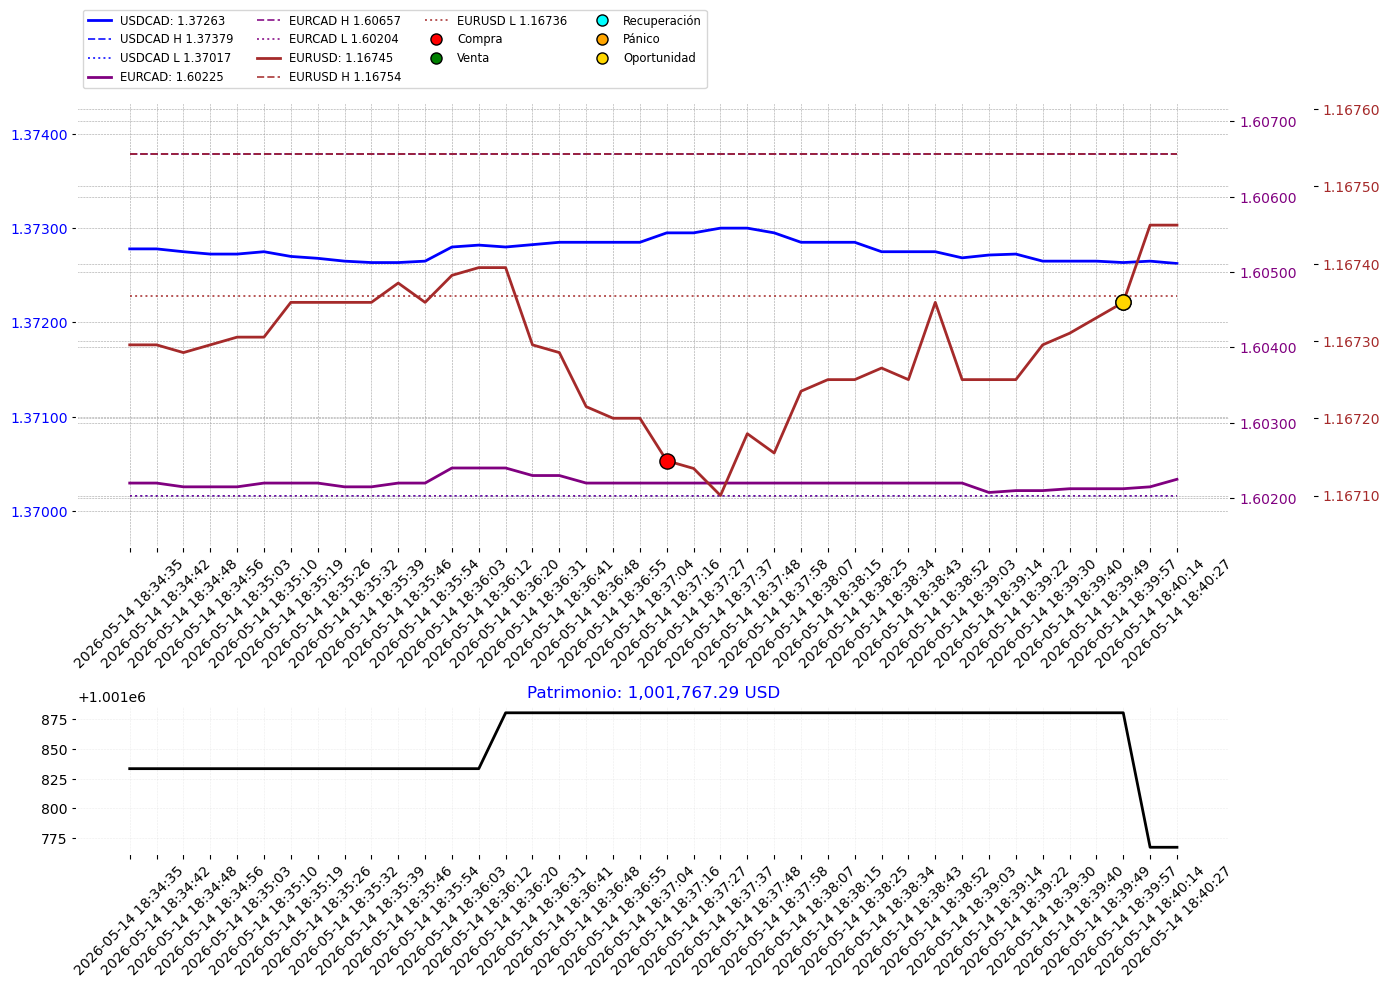

In [32]:
# --- CONFIGURACIÓN INICIAL ---
ib=conectar_ib()
simbolos_a_operar = ['USDCAD', 'EURCAD', 'EURUSD']
lista_contratos = []
estados = {}

folder_name = 'historics'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    log(f"📁 Carpeta '{folder_name}' creada.")

for sym in simbolos_a_operar:
    # 1. Pasar por modo_trabajo para obtener DF y Contrato calificado
    df_temp, contrato_temp = modo_trabajo_multiactivo(sym, x=1)
    if df_temp is not None:

        path_archivo = os.path.join(folder_name, f'{sym}_historico.csv')
        df_temp.to_csv(path_archivo, index=False) 
        log(f"📊 {sym}: Datos históricos guardados en {sym}_historico.csv")  

        # 2. Pasar por dia_anterior para obtener rangos iniciales
        h_ini, l_ini = dia_anterior_fix(df_temp)
        
        # 3. Guardar en la lista y crear su estado
        lista_contratos.append(contrato_temp)
        estados[sym] = {
            'compras_seguidas': 0,
            'ventas_fallidas': 0,
            'esperando_recuperacion': False,
            'prev_high': h_ini, # <--- Rango del "día anterior" aplicado
            'prev_low': l_ini,
            'last_entry_price': 0,
            'precios': [],
            'fechas': [],
            'operaciones': []
        }
        log(f"📊 {sym} inicializado con Rango: {l_ini:.5f} - {h_ini:.5f}")

# --- INICIO DEL BUCLE ---
if len(lista_contratos) == len(simbolos_a_operar):
    log("🚀 Todos los contratos listos. Iniciando bucle multiactivo...")
    bucle_3_divisas(lista_contratos, estados, ib)
else:
    log("❌ Error en la preparación de contratos.")

In [ ]:
ib.disconnect()